In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
from scipy.io import wavfile
import warnings
warnings.filterwarnings('ignore')

def analyze_audio_file(file_path, sr=None, figsize=(15, 12)):
    """
    Analizza un file audio e genera grafici per valutare la qualità e le informazioni contenute.
    
    Parameters:
    -----------
    file_path : str
        Percorso del file audio (.wav o .mp3)
    sr : int, optional
        Sample rate target per il caricamento (None per auto)
    figsize : tuple
        Dimensioni della figura principale
    """
    
    # Carica il file audio
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr)
        print(f"File caricato: {file_path}")
        print(f"Sample rate: {sample_rate} Hz")
        print(f"Durata: {len(audio)/sample_rate:.2f} secondi")
        print(f"Numero di campioni: {len(audio):,}")
        print(f"Dynamic range: [{audio.min():.4f}, {audio.max():.4f}]")
    except Exception as e:
        print(f"Errore nel caricamento del file: {e}")
        return
    
    # Calcola metriche aggiuntive
    rms = np.sqrt(np.mean(audio**2))
    crest_factor = np.max(np.abs(audio)) / rms if rms > 0 else 0
    snr_estimate = 20 * np.log10(rms / (np.std(audio - np.mean(audio)) + 1e-10))
    
    print(f"\nMetriche di qualità:")
    print(f"RMS: {rms:.6f}")
    print(f"Crest factor: {crest_factor:.2f}")
    print(f"SNR stimato: {snr_estimate:.2f} dB")
    
    # Crea la figura principale
    fig = plt.figure(figsize=figsize)
    
    # 1. Forma d'onda nel dominio del tempo
    plt.subplot(3, 2, 1)
    time = np.linspace(0, len(audio)/sample_rate, len(audio))
    plt.plot(time, audio, alpha=0.7, linewidth=0.5)
    plt.title('Forma d\'onda - Dominio del tempo')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Ampiezza')
    plt.grid(True, alpha=0.3)
    
    # 2. Spettro di frequenza
    plt.subplot(3, 2, 2)
    freqs, psd = signal.welch(audio, sample_rate, nperseg=1024)
    plt.semilogx(freqs, 10*np.log10(psd + 1e-10))
    plt.title('Densità spettrale di potenza')
    plt.xlabel('Frequenza (Hz)')
    plt.ylabel('Potenza (dB)')
    plt.grid(True, alpha=0.3)
    plt.xlim(20, sample_rate/2)
    
    # 3. Spettrogramma
    plt.subplot(3, 2, 3)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    librosa.display.specshow(D, sr=sample_rate, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spettrogramma')
    
    # 4. Distribuzione dell'ampiezza (istogramma)
    plt.subplot(3, 2, 4)
    plt.hist(audio, bins=100, alpha=0.7, density=True)
    plt.title('Distribuzione delle ampiezze')
    plt.xlabel('Ampiezza')
    plt.ylabel('Densità')
    plt.grid(True, alpha=0.3)
    
    # 5. Analisi spettrale dettagliata (bande di frequenza)
    plt.subplot(3, 2, 5)
    
    # Definisci bande di frequenza
    bands = {
        'Sub-bass (20-60Hz)': (20, 60),
        'Bass (60-250Hz)': (60, 250),
        'Mid (250-2kHz)': (250, 2000),
        'High-mid (2k-6kHz)': (2000, 6000),
        'Presence (6k-20kHz)': (6000, 20000)
    }
    
    band_energies = []
    band_labels = []
    
    for label, (low_freq, high_freq) in bands.items():
        mask = (freqs >= low_freq) & (freqs <= high_freq)
        if np.any(mask):
            energy = np.mean(psd[mask])
            band_energies.append(energy)
            band_labels.append(label)
    
    plt.bar(band_labels, 10*np.log10(np.array(band_energies) + 1e-10))
    plt.title('Energia per bande di frequenza')
    plt.ylabel('Energia (dB)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    
    # 6. Zero-crossing rate e analisi temporale
    plt.subplot(3, 2, 6)
    
    # Calcola zero-crossing rate per frame
    frame_length = 1024
    hop_length = 512
    zcr = librosa.feature.zero_crossing_rate(audio, 
                                           frame_length=frame_length, 
                                           hop_length=hop_length)[0]
    
    frames = range(len(zcr))
    time_zcr = librosa.frames_to_time(frames, sr=sample_rate, hop_length=hop_length)
    
    plt.plot(time_zcr, zcr)
    plt.title('Zero-Crossing Rate (indica contenuto armonico/percussivo)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('ZCR')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Analisi aggiuntiva per compressione MP3
    if file_path.lower().endswith('.mp3'):
        print(f"\n⚠️  File MP3 - Possibile perdita di informazioni:")
        
        # Analisi banda frequenziale
        max_freq = freqs[np.where(psd > np.max(psd)*0.001)[0][-1]]
        print(f"Banda frequenziale effettiva: ~{max_freq:.0f} Hz")
        
        if max_freq < 16000:
            print("→ Perdita significativa di alte frequenze (tipico della compressione MP3)")
        elif max_freq < 20000:
            print("→ Leggera perdita di alte frequenze")
        else:
            print("→ Banda frequenziale preservata")
    
    return {
        'audio': audio,
        'sample_rate': sample_rate,
        'rms': rms,
        'crest_factor': crest_factor,
        'snr_estimate': snr_estimate,
        'freqs': freqs,
        'psd': psd
    }

# Funzione per confrontare direttamente WAV vs MP3
def compare_wav_mp3(wav_path, mp3_path, sr=22050):
    """
    Confronta direttamente un file WAV e MP3 della stessa traccia.
    """
    print("=" * 60)
    print("CONFRONTO WAV vs MP3")
    print("=" * 60)
    
    # Analizza WAV
    print("\n📊 ANALISI FILE WAV:")
    wav_data = analyze_audio_file(wav_path, sr=sr)
    
    print("\n📊 ANALISI FILE MP3:")
    mp3_data = analyze_audio_file(mp3_path, sr=sr)
    
    if wav_data and mp3_data:
        # Confronto numerico
        print("\n" + "=" * 40)
        print("RIEPILOGO CONFRONTO")
        print("=" * 40)
        
        diff_rms = abs(wav_data['rms'] - mp3_data['rms'])
        diff_crest = abs(wav_data['crest_factor'] - mp3_data['crest_factor'])
        
        print(f"Differenza RMS: {diff_rms:.6f}")
        print(f"Differenza Crest Factor: {diff_crest:.2f}")
        
        # Confronto spettrale
        freq_mask = (wav_data['freqs'] <= 20000)
        spectral_diff = np.mean(np.abs(wav_data['psd'][freq_mask] - mp3_data['psd'][freq_mask]))
        print(f"Differenza spettrale media: {spectral_diff:.6f}")
        
        # Giudizio qualitativo
        if spectral_diff < 1e-6:
            print("✅ Qualità molto simile")
        elif spectral_diff < 1e-4:
            print("✅ Leggera differenza, buona qualità MP3")
        else:
            print("❌ Differenza significativa nella qualità")



File caricato: H:/music-ai/data/downloads/chopped-ghost-singing.mp3
Sample rate: 44100 Hz
Durata: 2.20 secondi
Numero di campioni: 97,089
Dynamic range: [-0.6513, 0.6368]

Metriche di qualità:
RMS: 0.266470
Crest factor: 2.44
SNR stimato: 0.00 dB


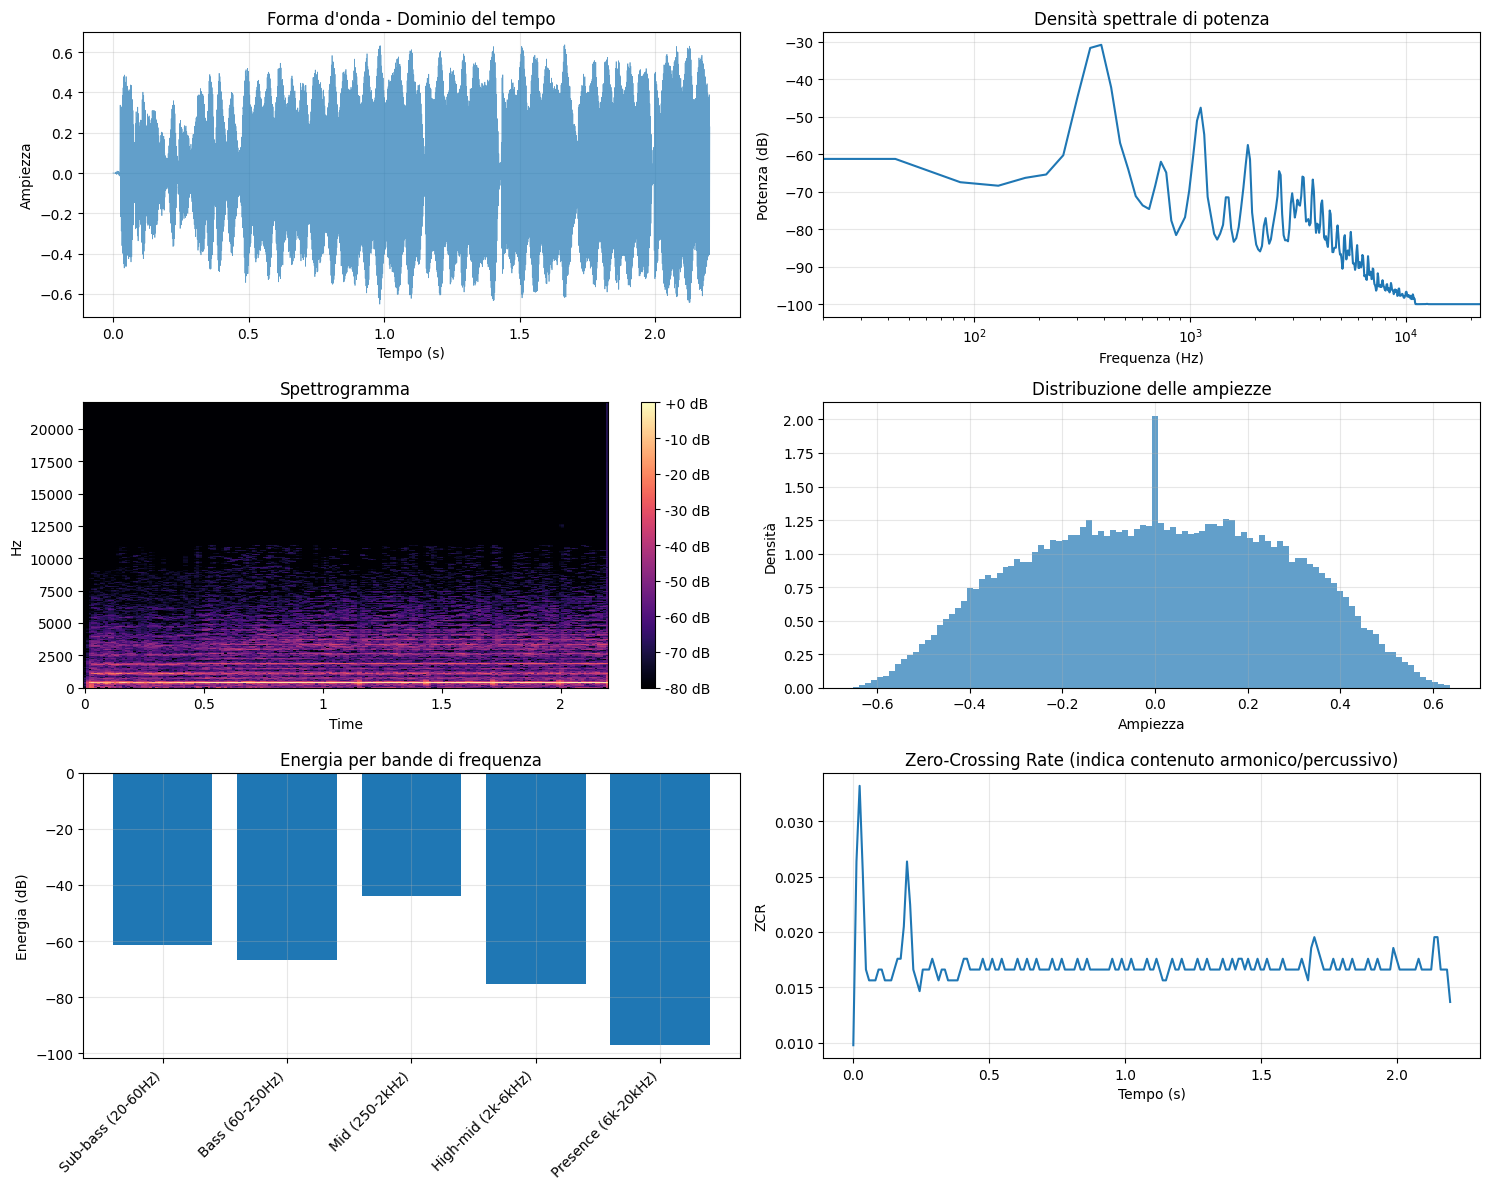


⚠️  File MP3 - Possibile perdita di informazioni:
Banda frequenziale effettiva: ~1852 Hz
→ Perdita significativa di alte frequenze (tipico della compressione MP3)
CONFRONTO WAV vs MP3

📊 ANALISI FILE WAV:
File caricato: H:/music-ai/data//data_processed/fsd50k/fsd50k_selected_samples/audios/359057.wav
Sample rate: 22050 Hz
Durata: 9.18 secondi
Numero di campioni: 202,326
Dynamic range: [-0.2129, 0.3293]

Metriche di qualità:
RMS: 0.070908
Crest factor: 4.64
SNR stimato: 0.00 dB


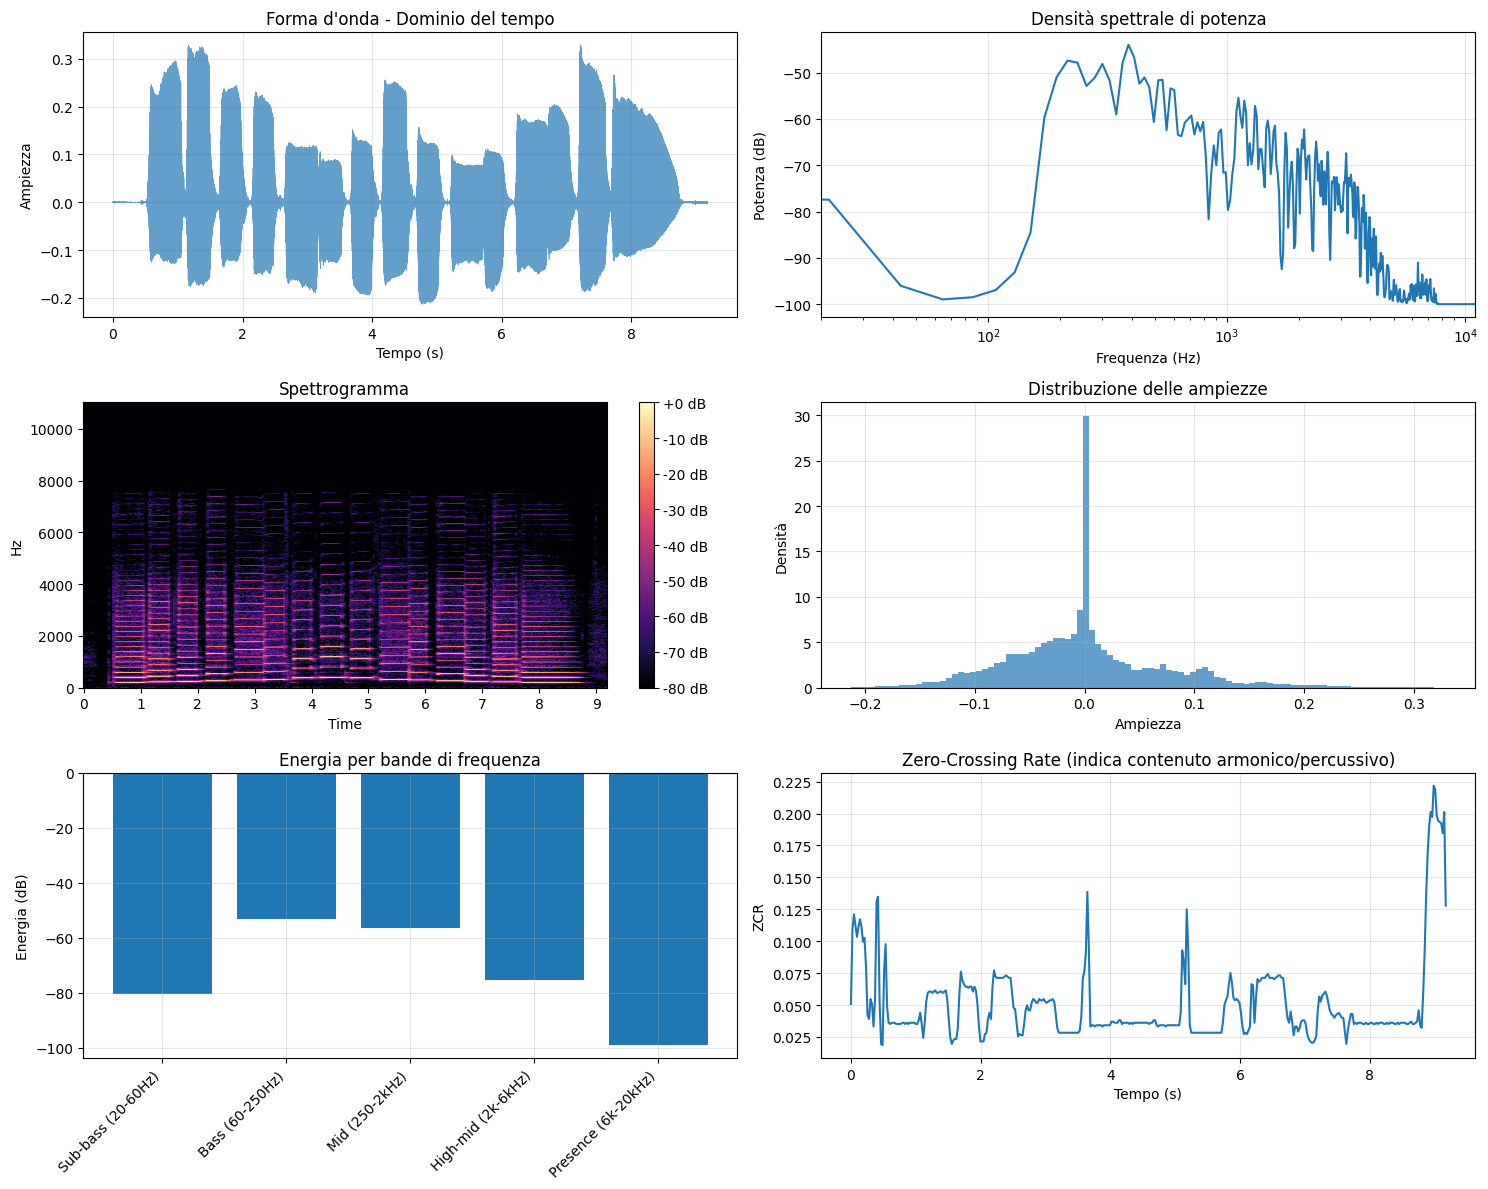


📊 ANALISI FILE MP3:
File caricato: H:/music-ai/data/downloads/chopped-ghost-singing.mp3
Sample rate: 22050 Hz
Durata: 2.20 secondi
Numero di campioni: 48,545
Dynamic range: [-0.6510, 0.6365]

Metriche di qualità:
RMS: 0.266468
Crest factor: 2.44
SNR stimato: 0.00 dB


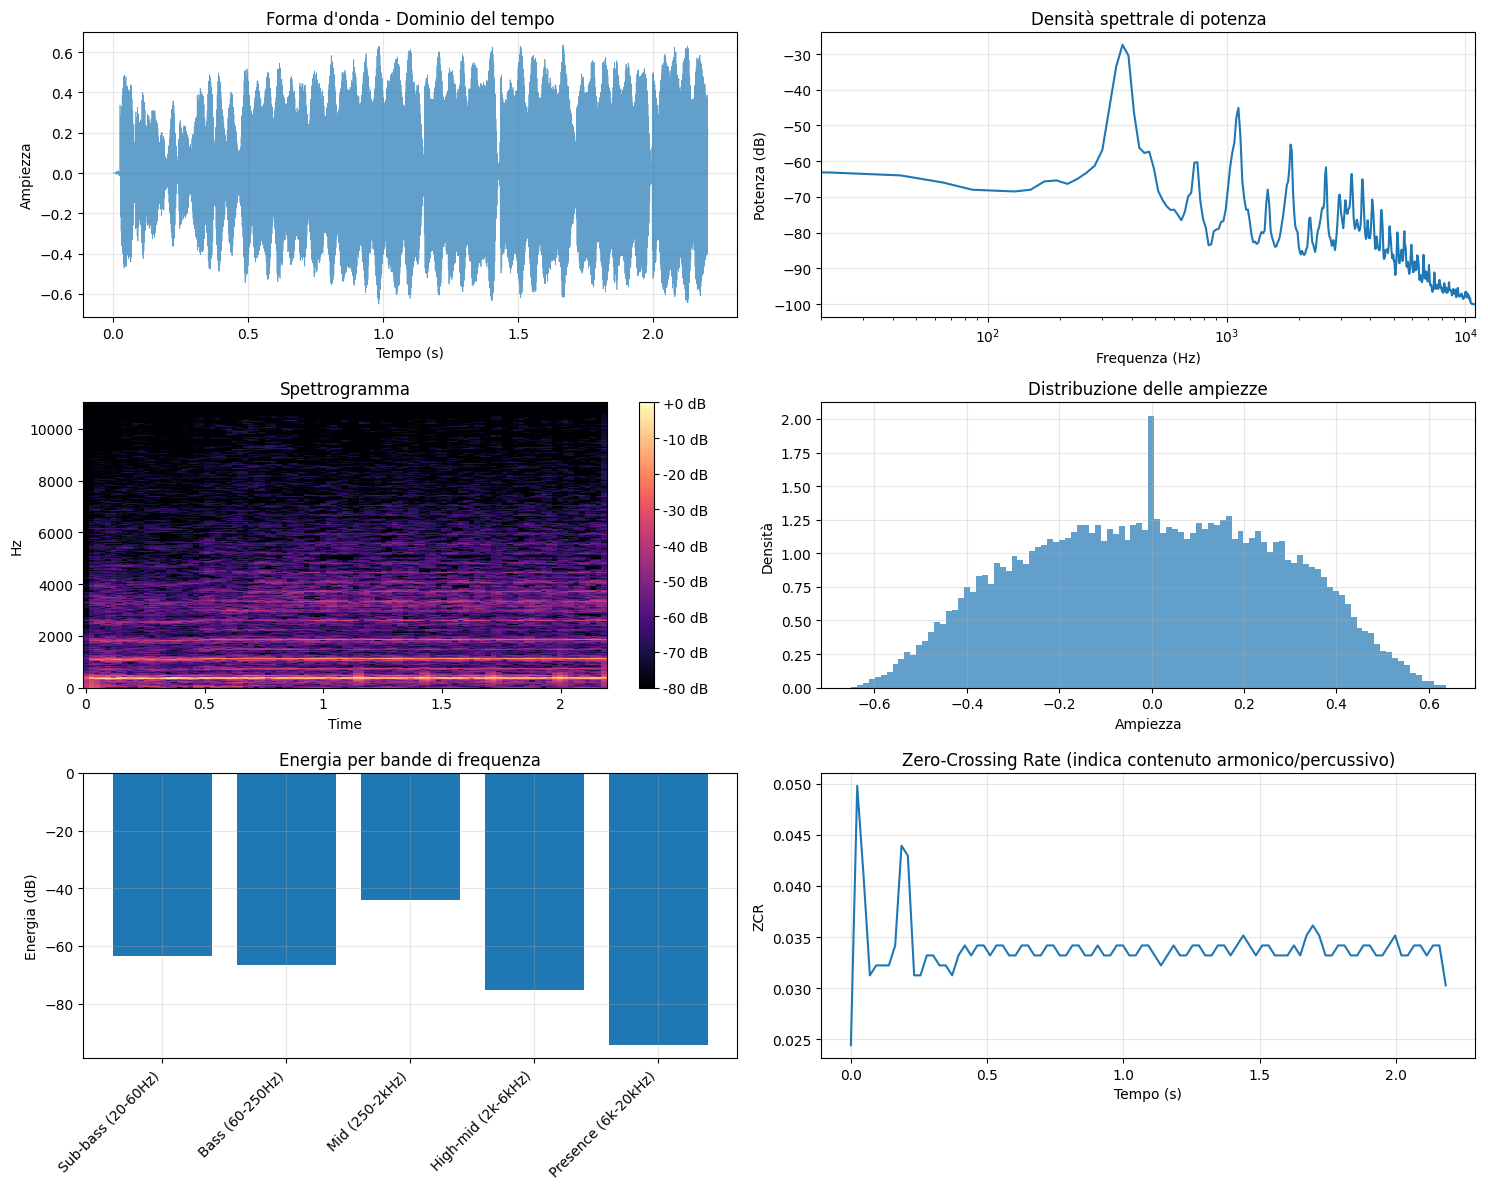


⚠️  File MP3 - Possibile perdita di informazioni:
Banda frequenziale effettiva: ~1873 Hz
→ Perdita significativa di alte frequenze (tipico della compressione MP3)

RIEPILOGO CONFRONTO
Differenza RMS: 0.195561
Differenza Crest Factor: 2.20
Differenza spettrale media: 0.000006
✅ Leggera differenza, buona qualità MP3


In [5]:

# Analizza un singolo file
path_mp3 = "H:/music-ai/data/downloads/chopped-ghost-singing.mp3"
path_wav = "H:/music-ai/data//data_processed/fsd50k/fsd50k_selected_samples/audios/359057.wav"
analyze_audio_file(path_mp3)

# Confronta WAV vs MP3
compare_wav_mp3(path_wav, path_mp3)
